Epoch 1/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 374764224.0000 - val_loss: 377885440.0000
Epoch 2/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 374764256.0000 - val_loss: 377885440.0000
Epoch 3/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 374764128.0000 - val_loss: 377885440.0000
Epoch 4/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 374764096.0000 - val_loss: 377885440.0000
Epoch 5/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 374764160.0000 - val_loss: 377885440.0000
Epoch 6/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 374764128.0000 - val_loss: 377885440.0000
Epoch 7/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 374763936.0000 - val_loss: 377885440.0000
Epoch 8/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 374764128.0000 - val_loss: 377885440.0000
Epoch 9/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 374764160.0000 - val_loss: 377885440.0000
Epoch 10/10
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 374764096.0000 - val_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:30:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


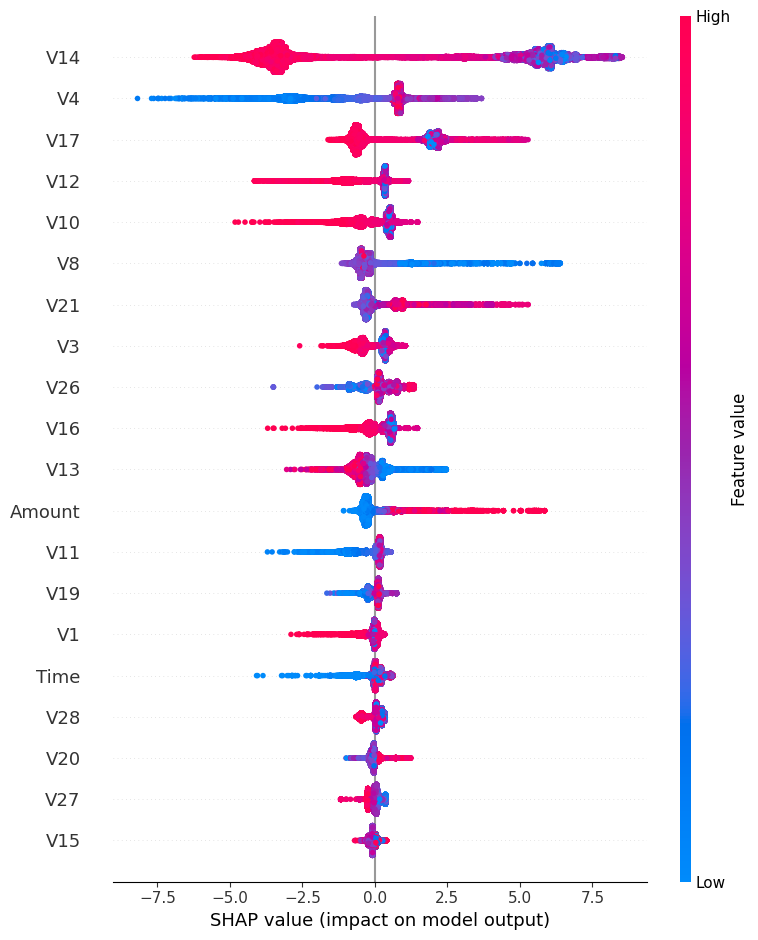

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:31:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


+--------------+-------------+----------+------------+-----------+
|              |   precision |   recall |   f1-score |   support |
|--------------+-------------+----------+------------+-----------|
| 0            |           1 |        1 |          1 |     29354 |
| 1            |           1 |        1 |          1 |     29354 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |     58708 |
| weighted avg |           1 |        1 |          1 |     58708 |
+--------------+-------------+----------+------------+-----------+

AUC-ROC Score: 1.0
Accuracy: 1.0


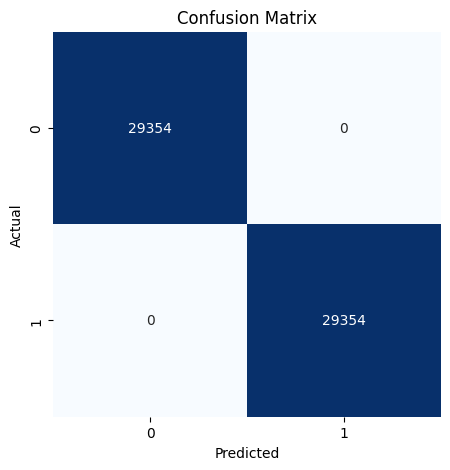

['columns.pkl']

In [ ]:
%pip install tabulate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
import shap
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tabulate import tabulate # Import tabulate for table formatting


# Load dataset
data = pd.read_csv("creditcard.csv")
data=data.sample(n=30000, random_state=42)

# Splitting features and target
X = data.drop(columns=['Class'])
y = data['Class']

# Handling missing values if any
X.fillna(X.median(), inplace=True)
# Handling Missing Values in Target Variable (y)
# Drop rows with NaN values in the target
data.dropna(subset=['Class'], inplace=True)

# Update X and y after dropping NaN values
X = data.drop(columns=['Class'])
y = data['Class']


# Data Preprocessing using Autoencoder
input_dim = X.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.fit(X, X, epochs=10, batch_size=256, shuffle=True, validation_split=0.1, verbose=1)

# Reconstruction error threshold
reconstructed = autoencoder.predict(X)
reconstruction_error = np.mean(np.abs(X - reconstructed), axis=1)
threshold = np.percentile(reconstruction_error, 95)
X['Anomaly_Score'] = reconstruction_error

# Handling Imbalanced Data using SMOTE + Tomek Links
smt = SMOTETomek(random_state=42)
X_resampled, y_resampled = smt.fit_resample(X.drop(columns=['Anomaly_Score']), y)

# Feature Scaling using RobustScaler
scaler = RobustScaler()
X_resampled = scaler.fit_transform(X_resampled)

# Feature Selection using SHAP
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=50, tree_method='hist')
xgb.fit(X_resampled, y_resampled)
explainer = shap.Explainer(xgb)
shap_values = explainer(X_resampled)
shap.summary_plot(shap_values, feature_names=data.drop(columns=['Class']).columns)

# Selecting top 10 important features
important_features = np.argsort(np.abs(shap_values.values).mean(0))[-10:]
X_selected = X_resampled[:, important_features]

# Model Training using XGBoost
xgb_final = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_final.fit(X_selected, y_resampled)

# Model Evaluation
y_pred = xgb_final.predict(X_selected)
y_pred_proba = xgb_final.predict_proba(X_selected)[:, 1]

# Calculate accuracy
accuracy = accuracy_score(y_resampled, y_pred)

# Print Classification Report in table format
report = classification_report(y_resampled, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(tabulate(report_df, headers='keys', tablefmt='psql'))  # Use 'psql' for a formatted table


print("\nAUC-ROC Score:", roc_auc_score(y_resampled, y_pred_proba))
print("Accuracy:", accuracy) # Print accuracy separately

# Confusion Matrix
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_resampled, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


import joblib

joblib.dump(xgb_final, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(important_features, "features.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("features.pkl")
files.download("columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>